# Análisis de variables financieras y de crédito

Este notebook prepara un subconjunto de variables para analizar información relacionada con el balance anual promedio, el estado de crédito en mora y la existencia de préstamos personales o hipotecarios. Aunque inicialmente el análisis estaba enfocado en la edad, el proceso actual se orienta a seleccionar columnas clave para comparar condiciones financieras de los clientes.

## Configuración del entorno

Se configura la ruta del proyecto para que Python pueda localizar correctamente los módulos definidos en `src` e importarlos dentro del notebook.

In [1]:
import sys
from pathlib import Path

project_dir = Path().resolve().parent
sys.path.append(str(project_dir))

## Carga y estandarización del dataset

Se carga la información desde el archivo CSV original y se estandarizan los encabezados del DataFrame. Este paso permite trabajar con nombres de columnas consistentes antes de seleccionar las variables que se utilizarán en el análisis.

In [2]:
import pandas as pd
from src.utils.paths import get_path_raw
from src.extract.extract import extract
from src.transform.clean_df import clean_heads

df = clean_heads(extract(get_path_raw('dataset.csv')))
df.columns

Index(['age', 'type_of_job', 'marital_status', 'education_level',
       'credit_in_default', 'average_yearly_balance', 'housing_loan',
       'personal_loan', 'contact_communication_type',
       'last_contact_day_of_the_month', 'v11', 'v12', 'v13', 'v14', 'v15',
       'v16', 'class'],
      dtype='str')

## Selección de variables para el análisis

Se crea un DataFrame reducido con las columnas necesarias para el análisis: edad, crédito en mora, balance anual promedio, préstamo hipotecario y préstamo personal. Esta selección concentra la información necesaria para construir cálculos o visualizaciones posteriores sobre el comportamiento financiero de los clientes.

In [3]:
from src.transform.transform import get_keep_columns

KEEP_COLUMNS = [
    'age',
    'credit_in_default',
    'average_yearly_balance',
    'housing_loan',
    'personal_loan'
]

df_part = get_keep_columns(df, KEEP_COLUMNS)

## Vista inicial del subconjunto

Se revisan las primeras filas del DataFrame reducido para confirmar que la selección de columnas se realizó correctamente y que las variables necesarias están disponibles para el análisis.


In [4]:
df_part.head()


,age,credit_in_default,average_yearly_balance,housing_loan,personal_loan
0,58,no,2143,yes,no
1,44,no,29,yes,no
2,33,no,2,yes,yes
3,47,no,1506,yes,no
4,33,no,1,no,no


## Resumen estadístico de variables numéricas

Se calculan métricas descriptivas para las variables numéricas del subconjunto. Este resumen permite identificar rangos, valores promedio y posibles diferencias entre la edad de los clientes y su balance anual promedio.


In [5]:
df_part[['age', 'average_yearly_balance']].describe()


,age,average_yearly_balance
count,45211.000000,45211.000000
mean,40.936210,1362.272058
std,10.618762,3044.765829
min,18.000000,-8019.000000
25%,33.000000,72.000000
50%,39.000000,448.000000
75%,48.000000,1428.000000
max,95.000000,102127.000000


## Distribución de variables de crédito y préstamos

Se calculan los conteos de clientes según su estado de crédito en mora, préstamo hipotecario y préstamo personal. Estos resultados ayudan a entender la composición general de la base antes de comparar balances o generar visualizaciones.


In [21]:
credit_columns = ['credit_in_default', 'housing_loan', 'personal_loan']

for column in credit_columns:
    print(f"Distribución de {column}:")
    print(df_part[column].value_counts().reset_index())
    print()


Distribución de credit_in_default:
  credit_in_default  count
0                no  44396
1               yes    815

Distribución de housing_loan:
  housing_loan  count
0          yes  25130
1           no  20081

Distribución de personal_loan:
  personal_loan  count
0            no  37967
1           yes   7244



## Relación entre edad y balance anual promedio

Aunque el análisis ya no está centrado únicamente en la edad, esta variable se conserva para observar su relación con el balance anual promedio. El gráfico de dispersión permite revisar si existe algún patrón general entre ambas variables.


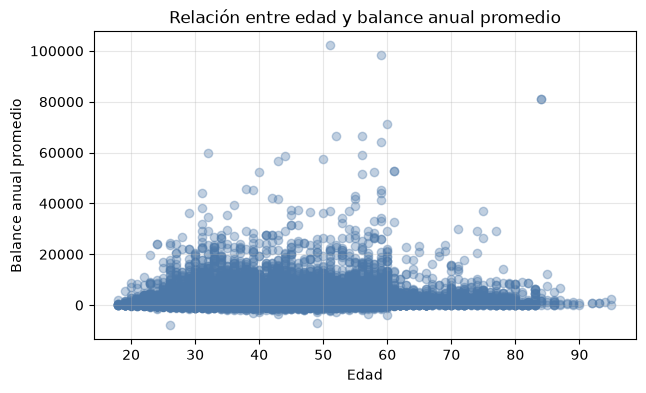

In [19]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 4))
plt.scatter(df_part['age'], df_part['average_yearly_balance'], alpha=0.35, color='#4c78a8')
plt.title('Relación entre edad y balance anual promedio')
plt.xlabel('Edad')
plt.ylabel('Balance anual promedio')
plt.grid(alpha=0.3)
plt.show()
